In [4]:
#Importing Liabraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [5]:
#Extracting CSV Dataset from System using Pandas Liabrary
data = pd.read_csv(r"C:\Users\sarth\Documents\DS_f proj\4_Heart Disease data.csv")

In [6]:
#Dataset Head Information
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [21]:
#All columns in a dataset
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'Heart_Disease'],
      dtype='object')

In [8]:
#Checking NULL values
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### **There are no missing values in the dataset.**

# **Percentage of people having heart disease**

In [9]:

# If 'num' is not a column, identify the correct column you want to group by
# For example, if you want to group by the column 'target', use:
num = data.groupby('target').size()

# Print the result
print(num)

target
0    499
1    526
dtype: int64


In [10]:
#Converting Numerical Data into Categorical Data
def heart_disease(row):
  if row==0:
    return 'Absence'
  elif row==1:
    return 'Presence'

In [11]:
#Applying converted data into our dataset with new column - Heart_Disease
data['Heart_Disease'] = data['target'].apply(heart_disease)
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Heart_Disease
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,Absence
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,Absence
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,Absence
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,Absence
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,Absence


In [12]:
hd = data.groupby('Heart_Disease')['target'].count()
hd

Heart_Disease
Absence     499
Presence    526
Name: target, dtype: int64

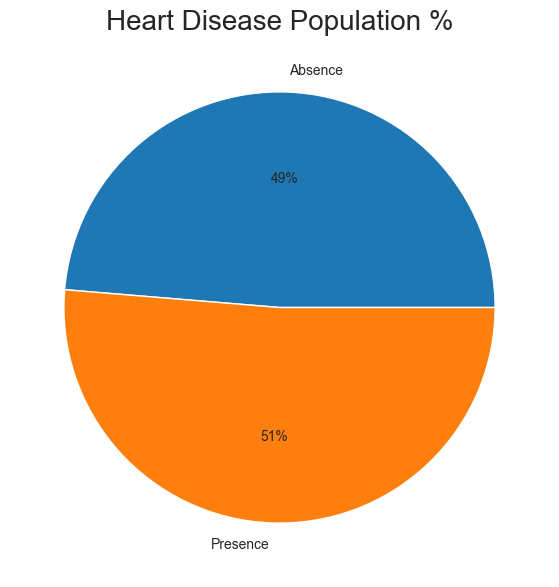

In [13]:
#Pie Chart creation of Heart Disease Population % Using Matplotlib
plt.figure(figsize=(10,7))
plt.pie(hd, labels=['Absence', 'Presence'], autopct='%0.0f%%')
plt.title('Heart Disease Population %' , fontsize=20)
plt.show()

### **From overall population, people who have heart disease are 51% and people who don't have heart disease are 49%.**
# **This means that people having heart disease are more than people who dont have heart disease.**



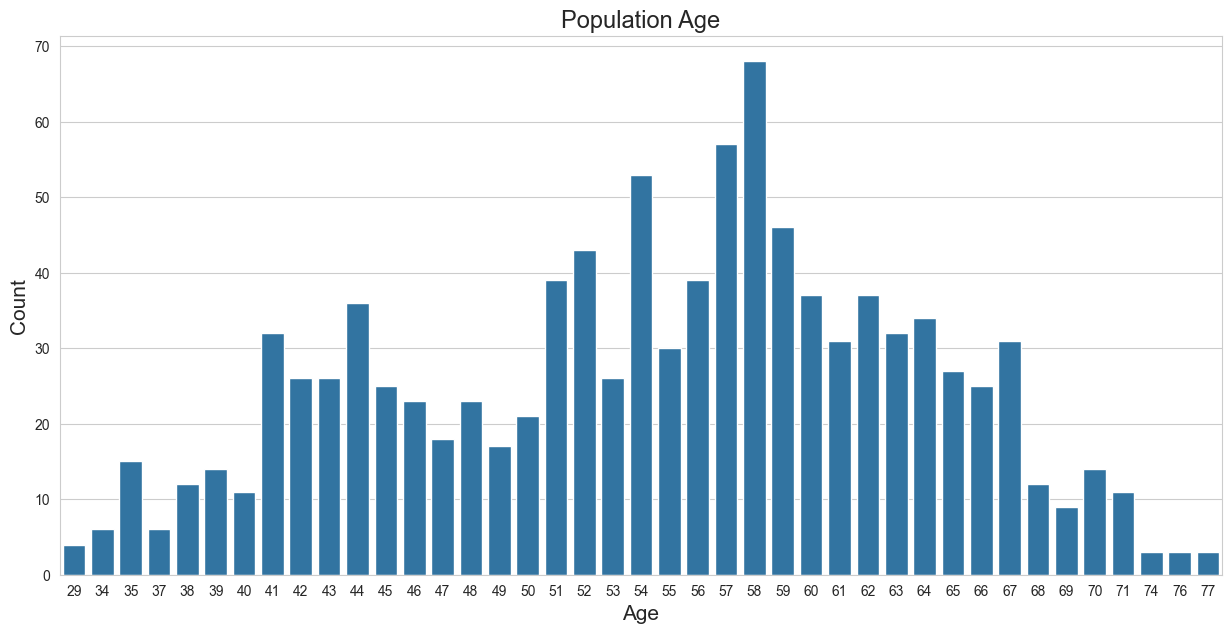

In [14]:
#Countplot Creation of Population Age using Matplotlib and Seaborn
plt.figure(figsize=(15,7))
sns.countplot(x='age', data=data)
plt.title('Population Age', fontsize=17)
plt.xlabel('Age', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.show()

In [15]:
#Creation of Data Frames from Each group
Young_Ages = data[(data['age'] >= 20) & (data['age'] <= 40)]
Middle_Ages = data[(data['age'] > 40) & (data['age'] <= 60)]
Elderly_Ages = data[data['age'] > 60]

C:\Users\sarth\AppData\Local\Temp\ipykernel_1140\292324014.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Young_Ages','Middle_Ages','Elderly_Ages'], y=[len(Young_Ages), len(Middle_Ages), len(Elderly_Ages)], palette='YlGnBu')


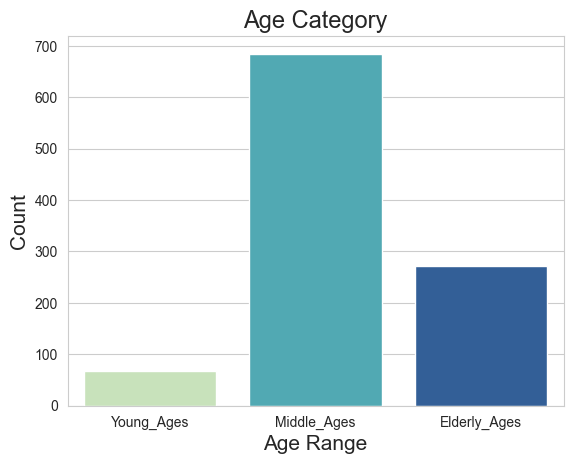

In [16]:
#Bar Plot Creation of Age Category
sns.barplot(x=['Young_Ages','Middle_Ages','Elderly_Ages'], y=[len(Young_Ages), len(Middle_Ages), len(Elderly_Ages)], palette='YlGnBu')
plt.title('Age Category', fontsize=17)
plt.xlabel('Age Range', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.show()

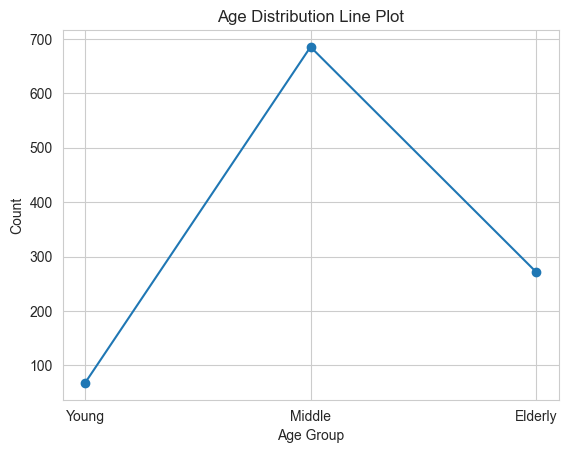

In [23]:
#Line Plot creation of age category
age_counts = [len(Young_Ages), len(Middle_Ages), len(Elderly_Ages)]
plt.plot(['Young', 'Middle', 'Elderly'], age_counts, marker='o')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Age Distribution Line Plot')
plt.show()

In [24]:
#Converting Numerical Data into Categorical Data
def gender(row):
  if row==1:
    return 'Male'
  elif row==0:
    return 'Female'

In [25]:
#Applying converted data into our dataset with new column
data['Gender']=data['sex'].apply(gender)
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Heart_Disease,Gender
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,Absence,Male
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,Absence,Male
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,Absence,Male
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,Absence,Male
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,Absence,Female


# **Creation of Bar Plot for Heart Disease by gender**

In [26]:
male_count = len(data[data['sex'] == 1])
female_count = len(data[data['sex'] == 0])

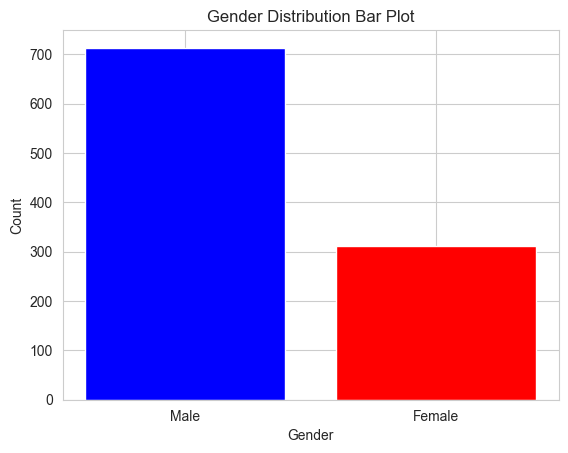

In [27]:
plt.bar(['Male', 'Female'], [male_count, female_count], color=['blue', 'red'])
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution Bar Plot')
plt.show()

**Thus Male has more heart disease than Female**